# mTSBench Dataset Analysis

Dataset-level analysis to finalise the **TOTAL_RUN_v2** fine-tuning strategy
(per-series normal prefix, no balancing, 50/50 file split on `*test.csv`).

For every CSV in mTSBench we report, **separately for the `train` / `test` / `val`
splits**:

* **point-level** anomaly stats — exact anomalous timesteps, anomaly rate, contiguous
  anomaly *events* and their lengths;
* **window-level** counts — how many sliding windows are *normal* vs *anomalous* under
  the training rule (a window is anomalous iff `>= ANOMALY_THRESHOLD` of its 64 future
  steps are anomalous), matching `prepare_total.py` exactly;
* **normal-signal availability** — whether each `*test.csv` has a real (>=256) normal
  zone for the `[normal|context]` prefix, or must be NaN-padded;
* **strategy stats** — dataset dominance, class imbalance, stride sensitivity, and the
  epoch/coverage math for choosing `NUM_STEPS`.

All stats are **label-only** (we read just `is_anomaly` + the header), so the full
719-file scan takes < 1 min. Note: 97 `*train.csv` files (all of SMD/SMAP/MSL) have
**no `is_anomaly` column** — those are treated as fully normal (the classic clean-train
convention).


In [1]:
import glob, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 160)

# ── Config — MUST match prepare_total.py / run_finetune_total.sh ──────────────
DATA_ROOT           = "/home/rajib/mTSBench/Datasets/mTSBench"
CONTEXT_LENGTH      = 512
PREDICTION_LENGTH   = 64
STRIDE              = 64          # train == test stride (contiguous test tiling)
NORMAL_SIGNAL_LENGTH= 256
ANOMALY_THRESHOLD   = 10          # window anomalous iff >= this many anomalous future steps
MIN_LENGTH          = 50
TEST_FRACTION       = 0.5         # 50/50 file split on *test.csv
SEED                = 42
min_req = max(MIN_LENGTH, CONTEXT_LENGTH + PREDICTION_LENGTH)
print("config OK")

config OK


In [2]:
# ── Helpers ──────────────────────────────────────────────────────────────────
def parse_name(path):
    """(dataset, series, split) from a csv path. split in {train,test,val,other}."""
    base = os.path.basename(path)
    ds = os.path.relpath(path, DATA_ROOT).split(os.sep)[0]
    m = re.match(r"(.*)_(train|test|val)\.csv$", base)
    return (ds, m.group(1), m.group(2)) if m else (ds, base[:-4], "other")

def read_labels(path):
    """(labels int8 array, n_features, has_label_col). Reads only is_anomaly + header.
    Files without an is_anomaly column (clean train splits) -> all-zero labels."""
    header = pd.read_csv(path, nrows=0).columns.tolist()
    has = "is_anomaly" in header
    feat_cols = [c for c in header if c not in ("timestamp", "is_anomaly")]
    if has:
        lab = pd.read_csv(path, usecols=["is_anomaly"])["is_anomaly"].values.astype(np.int8)
    else:
        n = sum(1 for _ in open(path)) - 1
        lab = np.zeros(max(n, 0), dtype=np.int8)
    return lab, len(feat_cols), has

def anomaly_events(labels):
    """(#contiguous anomaly regions, [region lengths])."""
    if labels.sum() == 0: return 0, []
    d = np.diff(np.concatenate([[0], (labels > 0).astype(np.int8), [0]]))
    starts, ends = np.where(d == 1)[0], np.where(d == -1)[0]
    return len(starts), (ends - starts).tolist()

def longest_normal_run(labels):
    """Longest contiguous run of normal (0) steps — the source of the normal prefix."""
    if labels.size == 0: return 0
    if labels.sum() == 0: return int(labels.size)
    best = cur = 0
    for v in (labels == 0):
        cur = cur + 1 if v else 0
        best = max(best, cur)
    return int(best)

def window_counts(labels, context, pred, stride, thr):
    """Sliding-window counts matching prepare_smd_split.create_pairs (label-only).
    Returns (total, anomalous, normal) windows."""
    total = labels.size
    if total < context + pred: return 0, 0, 0
    n_tot = n_anom = 0
    for t in range(context, total, stride):
        fe = t + pred
        if fe > total: break
        n_tot += 1
        if int(labels[t:fe].sum()) >= thr: n_anom += 1
    return n_tot, n_anom, n_tot - n_anom

def split_files(files, frac, seed):
    """prepare_total.split_files: >=2 files -> seeded 50/50; 1 file -> test-only."""
    files = sorted(files)
    if len(files) == 1: return [], list(files), "test_only"
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(files))
    n_test = max(1, min(len(files) - 1, int(round(len(files) * frac))))
    tidx = set(perm[:n_test].tolist())
    return ([files[i] for i in range(len(files)) if i not in tidx],
            [files[i] for i in sorted(tidx)], "file_split")
print("helpers OK")

helpers OK


In [3]:
# ── Full scan of every CSV (label-only; ~1 min) ──────────────────────────────
rows = []
for path in sorted(glob.glob(os.path.join(DATA_ROOT, "**", "*.csv"), recursive=True)):
    ds, series, split = parse_name(path)
    lab, F, has = read_labels(path)
    n_ev, ev_len = anomaly_events(lab)
    n_tot, n_anom, n_norm = window_counts(lab, CONTEXT_LENGTH, PREDICTION_LENGTH, STRIDE, ANOMALY_THRESHOLD)
    rows.append(dict(
        dataset=ds, series=series, split=split, path=path,
        length=int(lab.size), n_features=F, has_label_col=has,
        anomaly_points=int(lab.sum()),
        anomaly_rate=float(lab.mean()) if lab.size else 0.0,
        n_anomaly_events=n_ev, max_event_len=int(max(ev_len)) if ev_len else 0,
        mean_event_len=float(np.mean(ev_len)) if ev_len else 0.0,
        longest_normal_run=longest_normal_run(lab),
        win_total=n_tot, win_anom=n_anom, win_normal=n_norm))
df = pd.DataFrame(rows)
df.to_csv("mtsbench_file_stats.csv", index=False)
print(f"scanned {len(df)} files across {df.dataset.nunique()} datasets -> mtsbench_file_stats.csv")
df.head()

scanned 719 files across 19 datasets -> mtsbench_file_stats.csv


,dataset,series,split,path,length,n_features,has_label_col,anomaly_points,anomaly_rate,n_anomaly_events,max_event_len,mean_event_len,longest_normal_run,win_total,win_anom,win_normal
0,CalIt2,CalIt2_traffic,test,/home/rajib/mTSBench/Datasets/mTSBench/CalIt2/...,4032,2,True,138,0.034226,21,19,6.571429,655,55,3,52
1,CalIt2,CalIt2_traffic,train,/home/rajib/mTSBench/Datasets/mTSBench/CalIt2/...,940,2,True,0,0.000000,0,0,0.000000,940,6,0,6
2,CalIt2,CalIt2_traffic,val,/home/rajib/mTSBench/Datasets/mTSBench/CalIt2/...,1008,2,True,68,0.067460,8,17,8.500000,200,7,2,5
3,Daphnet,Daphnet_S01R01E1,test,/home/rajib/mTSBench/Datasets/mTSBench/Daphnet...,58880,9,True,4223,0.071722,14,973,301.642857,18440,912,76,836
4,Daphnet,Daphnet_S01R01E1,train,/home/rajib/mTSBench/Datasets/mTSBench/Daphnet...,13796,9,True,0,0.000000,0,0,0.000000,13796,207,0,207


## A. Point-level anomaly stats — `train` vs `test` vs `val`

Exact anomalous timesteps and rates, **each split separately**. This is where we
confirm the core premise of the strategy: **anomalies live in `*test.csv`** (and
`*val.csv`), while `*train.csv` is essentially clean — so the margin/hinge loss,
which needs anomalous windows, must be trained on the `test.csv` pool.

In [4]:
by_split = df.groupby("split").agg(
    files=("path", "size"),
    files_with_labels=("has_label_col", "sum"),
    total_points=("length", "sum"),
    anomaly_points=("anomaly_points", "sum"),
    anomaly_events=("n_anomaly_events", "sum"),
    win_total=("win_total", "sum"),
    win_anom=("win_anom", "sum"),
)
by_split["anom_point_rate_%"] = (100 * by_split.anomaly_points / by_split.total_points).round(3)
by_split["win_anom_%"] = (100 * by_split.win_anom / by_split.win_total.replace(0, np.nan)).round(2)
by_split

,files,files_with_labels,total_points,anomaly_points,anomaly_events,win_total,win_anom,anom_point_rate_%,win_anom_%
split,,,,,,,,,
test,351,351,44354495,5774412,45447,690147,105549,13.019,15.29
train,349,252,11739432,0,0,180487,0,0.000,0.00
val,19,19,604248,211089,8017,9279,3761,34.934,40.53


In [5]:
# Per-dataset x split: exact anomaly points (the "exact anomaly points ... separately" ask)
pts = df.pivot_table(index="dataset", columns="split", values="anomaly_points",
                     aggfunc="sum", fill_value=0)
rate = df.pivot_table(index="dataset", columns="split", values="anomaly_rate",
                      aggfunc="mean", fill_value=0.0).round(4)
pts.columns = [f"{c}_anom_pts" for c in pts.columns]
rate.columns = [f"{c}_rate" for c in rate.columns]
per_ds = pts.join(rate).sort_index()
per_ds

,test_anom_pts,train_anom_pts,val_anom_pts,test_rate,train_rate,val_rate
dataset,,,,,,
CalIt2,138,0,68,0.0342,0.0,0.0675
Daphnet,88146,0,2177,0.1799,0.0,0.5594
Exathlon,80374,0,3569,0.2414,0.0,0.1381
GECCO,1279,0,303,0.0154,0.0,0.0109
GHL,15606,0,863,0.0132,0.0,0.0100
Genesis,28,0,22,0.0030,0.0,0.0060
GutenTAG,9673,0,54,0.0322,0.0,0.0135
MITDB,3207892,0,45768,0.1313,0.0,0.3521
MSL,7553,0,101,0.1217,0.0,0.0831


## B. Window-level counts on the COMPLETE raw data (per dataset)

Sliding-window counts over **every file in mTSBench, as-is** — no train/test resampling
of our own; we simply tile each original series. A window's 64-step future horizon is
**anomalous** iff it contains `>= ANOMALY_THRESHOLD (=10)` anomalous steps (the same rule
the trainer uses in `derive_future_type`). Reported as: (1) raw totals per split, (2)
window counts per dataset x split, and (3) the headline per-dataset summary over all
files. *(No 50/50 split here — that belongs to the training step and appears only in
Section D.)*

In [6]:
win_by_split = df.groupby("split").agg(
    files=("path", "size"),
    win_total=("win_total", "sum"), win_anom=("win_anom", "sum"), win_normal=("win_normal", "sum"))
win_by_split["anom_%"] = (100 * win_by_split.win_anom / win_by_split.win_total.replace(0, np.nan)).round(2)
print("Sliding-window counts by split (raw, complete data):")
display(win_by_split)

Sliding-window counts by split (raw, complete data):


,files,win_total,win_anom,win_normal,anom_%
split,,,,,
test,351,690147,105549,584598,15.29
train,349,180487,0,180487,0.00
val,19,9279,3761,5518,40.53


In [7]:
# Window counts per dataset x split on the RAW data (parallel to the anomaly-points pivot)
wtot = df.pivot_table(index="dataset", columns="split", values="win_total", aggfunc="sum", fill_value=0)
wano = df.pivot_table(index="dataset", columns="split", values="win_anom",  aggfunc="sum", fill_value=0)
wtot.columns = [f"{c}_win" for c in wtot.columns]
wano.columns = [f"{c}_anomWin" for c in wano.columns]
win_ds_split = wtot.join(wano).sort_index()
print("Windows per dataset x split (raw). *_win = total windows, *_anomWin = anomalous:")
win_ds_split

Windows per dataset x split (raw). *_win = total windows, *_anomWin = anomalous:


,test_win,train_win,val_win,test_anomWin,train_anomWin,val_anomWin
dataset,,,,,,
CalIt2,55,6,7,3,0,2
Daphnet,9378,1936,52,1464,0,35
Exathlon,10306,2309,395,1246,0,57
GECCO,1290,422,424,45,0,8
GHL,17919,25593,1335,261,0,8
Genesis,137,42,48,1,0,1
GutenTAG,4440,210,54,195,0,1
MITDB,381499,84227,2023,54855,0,817
MSL,894,683,10,142,0,3


In [8]:
# ── Headline per-dataset stats over the COMPLETE raw data (ALL train+test+val files) ──
raw = df.groupby("dataset").agg(
    n_files=("path", "size"),
    train_f=("split", lambda s: int((s == "train").sum())),
    test_f =("split", lambda s: int((s == "test").sum())),
    val_f  =("split", lambda s: int((s == "val").sum())),
    n_features=("n_features", "first"),
    total_steps=("length", "sum"),
    anomaly_points=("anomaly_points", "sum"),
    anomaly_events=("n_anomaly_events", "sum"),
    win_total=("win_total", "sum"),
    win_anom=("win_anom", "sum"),
    win_normal=("win_normal", "sum"),
)
raw["anom_point_%"] = (100 * raw.anomaly_points / raw.total_steps).round(2)
raw["win_anom_%"]   = (100 * raw.win_anom / raw.win_total.replace(0, np.nan)).round(2)
raw = raw.sort_values("win_total", ascending=False)
print(f"COMPLETE mTSBench: {int(raw.win_total.sum()):,} windows "
      f"(anomalous={int(raw.win_anom.sum()):,}, "
      f"{100*raw.win_anom.sum()/raw.win_total.sum():.1f}%) over "
      f"{int(raw.n_files.sum())} files / {len(raw)} datasets.")
raw

COMPLETE mTSBench: 879,913 windows (anomalous=109,310, 12.4%) over 719 files / 19 datasets.


,n_files,train_f,test_f,val_f,n_features,total_steps,anomaly_points,anomaly_events,win_total,win_anom,win_normal,anom_point_%,win_anom_%
dataset,,,,,,,,,,,,,
MITDB,95,47,47,1,2,29985890,3253660,6983,467749,55672,412077,10.85,11.90
SVDB,157,78,78,1,2,17479157,1945691,14829,271819,40592,231227,11.13,14.93
GHL,29,14,14,1,16,2885151,16469,27,44847,269,44578,0.57,0.60
cicids,13,6,6,1,72,1760923,450897,20480,27403,7162,20241,25.61,26.14
Exathlon,64,30,33,1,20,867456,83943,89,13010,1303,11707,9.68,10.02
Daphnet,53,26,26,1,9,754987,90323,193,11366,1499,9867,11.96,13.19
SMD,37,18,18,1,38,696448,14792,199,10572,270,10302,2.12,2.55
SMAP,104,52,51,1,25,548376,51370,65,7695,837,6858,9.37,10.88
OPPORTUNITY,27,13,13,1,32,383269,6824,14,5756,116,5640,1.78,2.02


/tmp/ipykernel_1543491/283261695.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tr = df[df.split=="test"].groupby("dataset").apply(


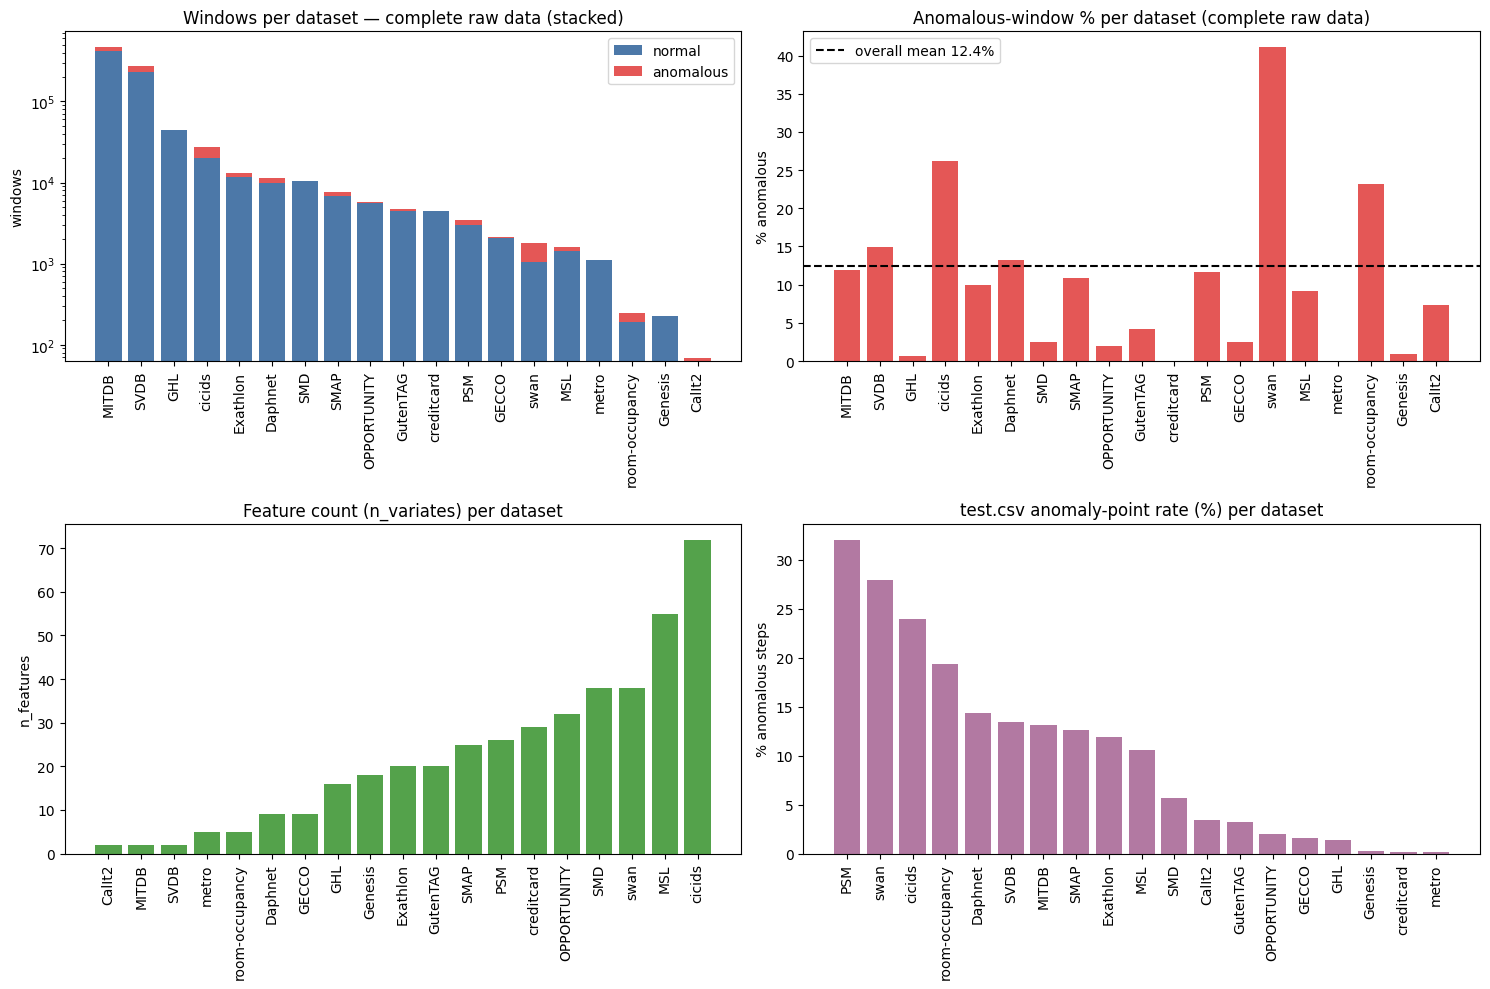

In [9]:
# ── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1) Windows per dataset (stacked normal/anom) over COMPLETE raw data — shows size
d = raw.sort_values("win_total", ascending=False)
ax = axes[0, 0]
ax.bar(d.index, d.win_normal, label="normal", color="#4C78A8")
ax.bar(d.index, d.win_anom, bottom=d.win_normal, label="anomalous", color="#E45756")
ax.set_title("Windows per dataset — complete raw data (stacked)"); ax.set_ylabel("windows")
ax.tick_params(axis="x", rotation=90); ax.legend(); ax.set_yscale("log")

# 2) Anomalous-window % per dataset (complete raw data)
ax = axes[0, 1]
pct = (100*d.win_anom/d.win_total.replace(0,np.nan)).fillna(0)
ax.bar(pct.index, pct.values, color="#E45756")
ax.axhline(100*raw.win_anom.sum()/raw.win_total.sum(), ls="--", c="k",
           label=f"overall mean {100*raw.win_anom.sum()/raw.win_total.sum():.1f}%")
ax.set_title("Anomalous-window % per dataset (complete raw data)"); ax.set_ylabel("% anomalous")
ax.tick_params(axis="x", rotation=90); ax.legend()

# 3) Feature-count per dataset
ax = axes[1, 0]
fc = df.groupby("dataset").n_features.first().sort_values()
ax.bar(fc.index, fc.values, color="#54A24B")
ax.set_title("Feature count (n_variates) per dataset"); ax.set_ylabel("n_features")
ax.tick_params(axis="x", rotation=90)

# 4) Point-level anomaly rate: test vs val per dataset
ax = axes[1, 1]
tr = df[df.split=="test"].groupby("dataset").apply(
        lambda s: 100*s.anomaly_points.sum()/max(1,s.length.sum())).sort_values(ascending=False)
ax.bar(tr.index, tr.values, color="#B279A2")
ax.set_title("test.csv anomaly-point rate (%) per dataset"); ax.set_ylabel("% anomalous steps")
ax.tick_params(axis="x", rotation=90)

plt.tight_layout(); plt.show()

## C. Per-series normal-signal availability

The `[normal | context]` instruction prefixes every window with a 256-step reference
normal signal carved from that file's normal zones. If a `*test.csv` has **no
contiguous normal run >= 256**, the prefix is NaN-padded — a weaker instruction. Here
we quantify how many test files that affects.

In [10]:
test_files = df[df.split == "test"].copy()
test_files["normal_ok"] = test_files.longest_normal_run >= NORMAL_SIGNAL_LENGTH
n_ok = int(test_files.normal_ok.sum()); n_tot = len(test_files)
print(f"test.csv files with a real >= {NORMAL_SIGNAL_LENGTH}-step normal zone: "
      f"{n_ok}/{n_tot} ({100*n_ok/n_tot:.1f}%)")
print(f"NaN-padded (short/no normal zone): {n_tot-n_ok}/{n_tot}")
print(f"fully-anomaly-free test files (longest_normal_run == length): "
      f"{int((test_files.longest_normal_run==test_files.length).sum())}")
# Per-dataset breakdown of padded files
pad = test_files.groupby("dataset").agg(
    files=("path","size"), normal_ok=("normal_ok","sum"))
pad["padded"] = pad.files - pad.normal_ok
pad[pad.padded > 0].sort_values("padded", ascending=False)

test.csv files with a real >= 256-step normal zone: 349/351 (99.4%)
NaN-padded (short/no normal zone): 2/351
fully-anomaly-free test files (longest_normal_run == length): 0


,files,normal_ok,padded
dataset,,,
Exathlon,33,31,2


## D. Training-strategy stats & takeaways

**This is the only section that applies the 50/50 file split** — because the actual
training set is the train half of the `*test.csv` files (see `prepare_total.py`). Sections
A-C above are pure raw-data statistics. The numbers here drive `NUM_STEPS`, stride, and
whether to rebalance.

In [11]:
# Build the TRAIN POOL = 50/50 train half of *test.csv (only used for strategy math here)
test_df = df[df.split == "test"]
pool_rows = []
for ds, sub in test_df.groupby("dataset"):
    tr, te, mode = split_files(sub.path.tolist(), TEST_FRACTION, SEED)
    s = sub[sub.path.isin(tr)]
    pool_rows.append(dict(dataset=ds, files=len(tr),
        win_total=int(s.win_total.sum()), win_anom=int(s.win_anom.sum()),
        win_normal=int(s.win_normal.sum())))
train_pool = pd.DataFrame(pool_rows).set_index("dataset")
TP = int(train_pool.win_total.sum())
print(f"TRAIN POOL (train half of *test.csv): {TP:,} windows, "
      f"{100*train_pool.win_anom.sum()/TP:.1f}% anomalous\n")

# 1) Dataset dominance
d = train_pool.sort_values("win_total", ascending=False)
top2 = d.head(2)
print("== DOMINANCE ==")
print(f"  top-2 datasets ({', '.join(top2.index)}) = "
      f"{100*top2.win_total.sum()/TP:.1f}% of all train windows")
print(f"  datasets contributing < 1% each: "
      f"{sorted(d[d.win_total < 0.01*TP].index.tolist())}")

# 2) Class imbalance + datasets with no anomaly signal
print("\n== CLASS BALANCE ==")
print(f"  overall: {100*train_pool.win_anom.sum()/TP:.1f}% anomalous windows")
zero = sorted(train_pool[train_pool.win_anom == 0].index.tolist())
print(f"  datasets with ZERO anomalous train windows (no anomaly signal): {zero}")

# 3) Stride sensitivity — total train windows & rows at different strides
print("\n== STRIDE SENSITIVITY (train pool) ==")
train_paths = []
for ds, sub in test_df.groupby("dataset"):
    tr, _, _ = split_files(sub.path.tolist(), TEST_FRACTION, SEED)
    train_paths += [(ds, p) for p in tr]
lab_cache = {p: read_labels(p) for _, p in train_paths}
feat_of = {p: lab_cache[p][1] for _, p in train_paths}
for stride in (64, 128, 256):
    wt = rows_ = 0
    for _, p in train_paths:
        lab, F, _ = lab_cache[p]
        t, _, _ = window_counts(lab, CONTEXT_LENGTH, PREDICTION_LENGTH, stride, ANOMALY_THRESHOLD)
        wt += t; rows_ += t * F
    eb = 160 * 2
    print(f"  stride={stride:3d}: {wt:>8,} windows | {rows_:>11,} rows "
          f"| 1 epoch = {rows_/eb:>6,.0f} steps")

# 4) Coverage / epoch math for the chosen NUM_STEPS (rows basis, batch counts rows)
print("\n== COVERAGE @ stride 64 (effective batch = 160 x GA2 = 320 rows/step) ==")
total_rows = sum(t * F for (_, p) in train_paths
                 for t, _, _ in [window_counts(lab_cache[p][0], CONTEXT_LENGTH,
                                 PREDICTION_LENGTH, 64, ANOMALY_THRESHOLD)]
                 for F in [lab_cache[p][1]])
eb = 320
print(f"  total training rows (windows x n_variates) = {total_rows:,}")
print(f"  1 nominal epoch = {total_rows/eb:,.0f} steps")
for steps in (6500, 13000, 19000, 19500):
    ep = steps*eb/total_rows
    print(f"  NUM_STEPS={steps:>6}: {ep:.2f} epochs -> ~{100*(1-np.exp(-ep)):.0f}% of rows seen >=1x")

TRAIN POOL (train half of *test.csv): 340,523 windows, 14.8% anomalous

== DOMINANCE ==
  top-2 datasets (MITDB, SVDB) = 87.5% of all train windows
  datasets contributing < 1% each: ['CalIt2', 'GECCO', 'Genesis', 'GutenTAG', 'MSL', 'OPPORTUNITY', 'PSM', 'SMAP', 'SMD', 'creditcard', 'metro', 'room-occupancy', 'swan']

== CLASS BALANCE ==
  overall: 14.8% anomalous windows
  datasets with ZERO anomalous train windows (no anomaly signal): ['CalIt2', 'GECCO', 'Genesis', 'PSM', 'creditcard', 'metro', 'swan']

== STRIDE SENSITIVITY (train pool) ==


  stride= 64:  340,523 windows |   2,079,011 rows | 1 epoch =  6,497 steps


  stride=128:  170,293 windows |   1,040,178 rows | 1 epoch =  3,251 steps


  stride=256:   85,180 windows |     520,773 rows | 1 epoch =  1,627 steps

== COVERAGE @ stride 64 (effective batch = 160 x GA2 = 320 rows/step) ==


  total training rows (windows x n_variates) = 2,079,011
  1 nominal epoch = 6,497 steps
  NUM_STEPS=  6500: 1.00 epochs -> ~63% of rows seen >=1x
  NUM_STEPS= 13000: 2.00 epochs -> ~86% of rows seen >=1x
  NUM_STEPS= 19000: 2.92 epochs -> ~95% of rows seen >=1x
  NUM_STEPS= 19500: 3.00 epochs -> ~95% of rows seen >=1x


## E. Anomaly-threshold selection — where do the anomaly points land?

For every **training window** (train half of `*test.csv`, stride 64) we count how many of
its 64 horizon steps are anomalous, then sweep the window threshold. At each threshold we
report how many windows are labeled anomalous vs normal, and — the point of your question —
how many anomaly points **leak into windows labeled NORMAL** (trained as if normal) vs are
**captured in anomalous windows**, and how many **normal points get trapped inside
anomalous windows** (pushed up wrongly). Use this to choose `ANOMALY_THRESHOLD`.

In [12]:
# Per-window anomaly-point counts over the TRAINING POOL (train half of *test.csv, tagged by dataset)
tp_files = []
for ds, sub in df[df.split == "test"].groupby("dataset"):
    tr, _, _ = split_files(sub.path.tolist(), TEST_FRACTION, SEED)
    tp_files += [(ds, p) for p in tr]

win_ds, win_cnt = [], []
for ds, p in tp_files:
    lab, _, _ = read_labels(p)
    L = lab.size
    if L < CONTEXT_LENGTH + PREDICTION_LENGTH:
        continue
    for t in range(CONTEXT_LENGTH, L, STRIDE):
        fe = t + PREDICTION_LENGTH
        if fe > L:
            break
        win_ds.append(ds); win_cnt.append(int(lab[t:fe].sum()))
win_cnt = np.array(win_cnt); win_ds = np.array(win_ds)
print(f"training windows: {len(win_cnt):,}  |  total anomaly points inside them: {int(win_cnt.sum()):,}")

# Distribution of anomaly-points-per-window (how many of the 64 horizon steps are anomalous)
buckets = [(0,0),(1,4),(5,9),(10,15),(16,31),(32,47),(48,63),(64,64)]
hist = pd.DataFrame([dict(anom_pts_in_window=(f"{lo}-{hi}" if lo != hi else str(lo)),
        windows=int(((win_cnt >= lo) & (win_cnt <= hi)).sum())) for lo, hi in buckets])
hist["pct_of_windows"] = (100 * hist.windows / len(win_cnt)).round(2)
print("Anomaly points per 64-step window:")
hist

training windows: 340,523  |  total anomaly points inside them: 2,717,318
Anomaly points per 64-step window:


,anom_pts_in_window,windows,pct_of_windows
0,0,283800,83.34
1,1-4,3779,1.11
2,5-9,2484,0.73
3,10-15,2130,0.63
4,16-31,5674,1.67
5,32-47,5928,1.74
6,48-63,7373,2.17
7,64,29355,8.62


In [13]:
# Threshold sweep: window counts + anomaly-point accounting at each candidate threshold
def threshold_sweep(counts, thresholds, pred=PREDICTION_LENGTH):
    tot, W = int(counts.sum()), len(counts)
    rows = []
    for thr in thresholds:
        a = counts >= thr                       # windows labeled ANOMALOUS at this threshold
        na, nn = int(a.sum()), int((~a).sum())
        ap_cap  = int(counts[a].sum())          # anomaly pts inside anomalous windows (captured)
        ap_leak = int(counts[~a].sum())         # anomaly pts inside NORMAL windows (leaked)
        np_trap = int((pred - counts[a]).sum()) # normal pts inside anomalous windows (trapped)
        rows.append(dict(threshold=thr,
            anom_windows=na, normal_windows=nn,
            win_anom_pct=round(100 * na / W, 2),
            anom_pts_captured=ap_cap, anom_pts_leaked_to_normal=ap_leak,
            pct_anom_pts_captured=round(100 * ap_cap / max(1, tot), 2),
            normal_pts_in_anom_win=np_trap,
            anom_window_purity_pct=round(100 * ap_cap / max(1, pred * na), 1)))
    return pd.DataFrame(rows).set_index("threshold")

sweep = threshold_sweep(win_cnt, [1, 2, 3, 5, 8, 10, 13, 16, 20, 32, 48, 64])
print("Higher threshold -> fewer/purer anomaly windows but MORE anomaly points leak into normal windows.")
sweep

Higher threshold -> fewer/purer anomaly windows but MORE anomaly points leak into normal windows.


,anom_windows,normal_windows,win_anom_pct,anom_pts_captured,anom_pts_leaked_to_normal,pct_anom_pts_captured,normal_pts_in_anom_win,anom_window_purity_pct
threshold,,,,,,,,
1,56723,283800,16.66,2717318,0,100.00,912954,74.9
2,55911,284612,16.42,2716506,812,99.97,861798,75.9
3,54917,285606,16.13,2714518,2800,99.90,800170,77.2
5,52944,287579,15.55,2707687,9631,99.65,680729,79.9
8,51237,289286,15.05,2697707,19611,99.28,581461,82.3
10,50460,290063,14.82,2691126,26192,99.04,538314,83.3
13,49383,291140,14.50,2679302,38016,98.60,481210,84.8
16,48330,292193,14.19,2664562,52756,98.06,428558,86.1
20,46945,293578,13.79,2640347,76971,97.17,364133,87.9


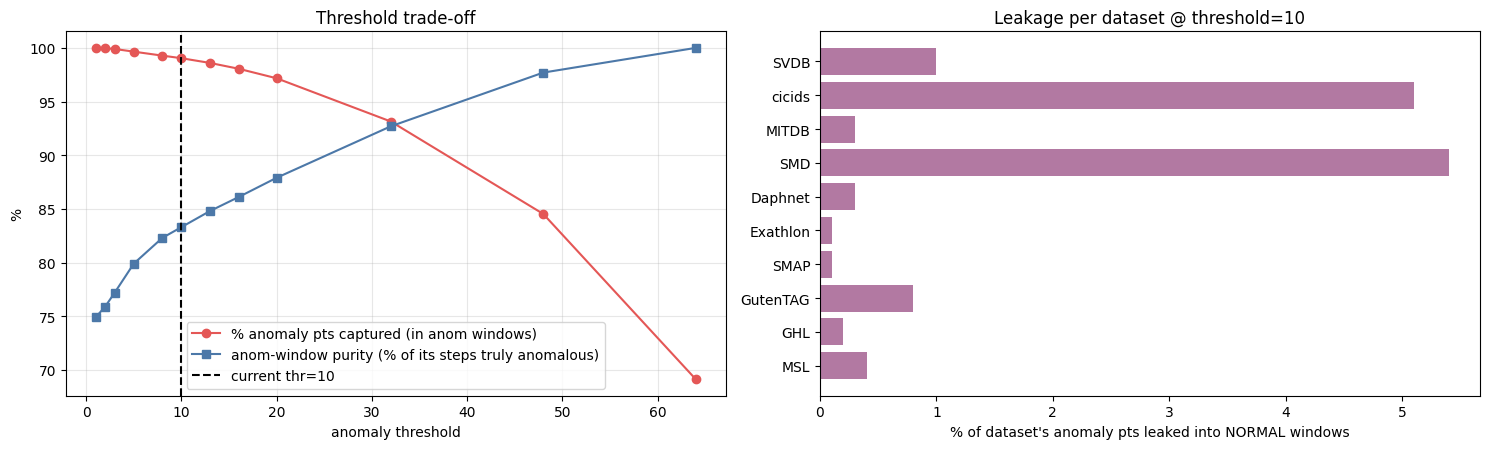

Per-dataset window/point counts at threshold=10 (anom_pts_leaked_to_normal = trained as normal):


,anom_windows,normal_windows,anom_pts_captured,anom_pts_leaked_to_normal,pct_leaked
dataset,,,,,
SVDB,23036,88252,1095682,10685,1.0
cicids,3308,8852,199583,10636,5.1
MITDB,21625,165066,1248722,4309,0.3
SMD,101,2103,4508,258,5.4
Daphnet,822,4790,48274,132,0.3
Exathlon,774,4783,47996,61,0.1
SMAP,467,2558,28713,37,0.1
GutenTAG,95,2125,4761,36,0.8
GHL,93,8601,5444,13,0.2


In [14]:
# Visualise the trade-off + per-dataset leakage at the CURRENT threshold
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
ax = axes[0]
ax.plot(sweep.index, sweep.pct_anom_pts_captured, "-o", color="#E45756",
        label="% anomaly pts captured (in anom windows)")
ax.plot(sweep.index, sweep.anom_window_purity_pct, "-s", color="#4C78A8",
        label="anom-window purity (% of its steps truly anomalous)")
ax.axvline(ANOMALY_THRESHOLD, ls="--", c="k", label=f"current thr={ANOMALY_THRESHOLD}")
ax.set_xlabel("anomaly threshold"); ax.set_ylabel("%"); ax.set_title("Threshold trade-off")
ax.legend(); ax.grid(alpha=.3)

thr = ANOMALY_THRESHOLD
per = []
for ds in np.unique(win_ds):
    c = win_cnt[win_ds == ds]; a = c >= thr
    per.append(dict(dataset=ds, anom_windows=int(a.sum()), normal_windows=int((~a).sum()),
        anom_pts_captured=int(c[a].sum()), anom_pts_leaked_to_normal=int(c[~a].sum())))
per = pd.DataFrame(per).set_index("dataset")
per["pct_leaked"] = (100 * per.anom_pts_leaked_to_normal /
                     (per.anom_pts_captured + per.anom_pts_leaked_to_normal).replace(0, np.nan)).round(1)
per = per.sort_values("anom_pts_leaked_to_normal", ascending=False)
top = per.head(10)
ax = axes[1]
ax.barh(top.index[::-1], top.pct_leaked[::-1], color="#B279A2")
ax.set_xlabel("% of dataset's anomaly pts leaked into NORMAL windows")
ax.set_title(f"Leakage per dataset @ threshold={thr}")
plt.tight_layout(); plt.show()
print(f"Per-dataset window/point counts at threshold={thr} "
      f"(anom_pts_leaked_to_normal = trained as normal):")
per

### Takeaways

* **`train.csv` is unusable for the anomaly objective** — ~0% anomalous points, so the
  hinge term would get no `L_bad` signal there. Training on the `test.csv` pool is
  correct. (`val.csv` is anomaly-*rich* — a candidate held-out eval set.)
* **Two ECG datasets (MITDB + SVDB) dominate** the unbalanced train pool (~85–90% of
  windows). This is the deliberate "no balancing" consequence; if per-dataset VUS-PR
  later shows the model over-fitting ECG morphology at the expense of other domains,
  a uniform `STRIDE` increase (see the stride table) or light per-dataset capping is
  the lever — but that reintroduces the v1 balancing we removed on purpose.
* **7 single-file datasets contribute no training windows** (test-only) and several
  more have **zero anomalous windows** — they are evaluated but never teach the model.
* **Normal-signal coverage** tells you how many test series get a real vs NaN-padded
  `[normal|context]` instruction; heavily-padded datasets are where the prefix helps
  least.
* Use the **coverage table** to set `NUM_STEPS`: ~13k steps ≈ 2 epochs (~86% of rows
  seen), ~19k ≈ 3 epochs (~95%).
